In [1]:
!pip install pypdf 

In [2]:
#import package and its set of stopwords
from wordcloud import WordCloud, STOPWORDS
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image # converting images into arrays
print ('Wordcloud imported!')

Wordcloud imported!


In [3]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jdavid/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import urllib.request
import io
from pypdf import PdfReader

# 1. Obtener los datos del PDF desde la URL
# La llamada a urlopen.read() devuelve los bytes del archivo PDF
pdf_bytes = urllib.request.urlopen('https://www.casareal.es/sitios/listasaux/Documents/Mensajenavidad20241224/20241224_mensaje_navidad_esp_rey_felipe.pdf').read()

# 2. Abrir los bytes en memoria como un archivo (stream)
# Esto es necesario para que PdfReader pueda leer los datos como si vinieran de un archivo.
pdf_file = io.BytesIO(pdf_bytes)

# 3. Crear un objeto PdfReader
reader = PdfReader(pdf_file)

# 4. Extraer el texto de todas las páginas y unirlas
discurso_rey = ""
for page in reader.pages:
    # get_text() extrae el contenido de texto de la página
    discurso_rey += page.extract_text() + "\n" # Agregamos un salto de línea entre páginas

# El resultado ahora está en la variable 'alice_novel' como una cadena de texto (str)
#print(alice_novel[:500]) # Imprime los primeros 500 caracteres para verificar

In [13]:
from nltk.corpus import stopwords
stopwords = stopwords.words('spanish')

In [6]:

stopwords.append("palacio")
discurso_wc = WordCloud(collocations=False, stopwords=stopwords,width=800, height=400)

# generate the word cloud
discurso_wc.generate(discurso_rey)

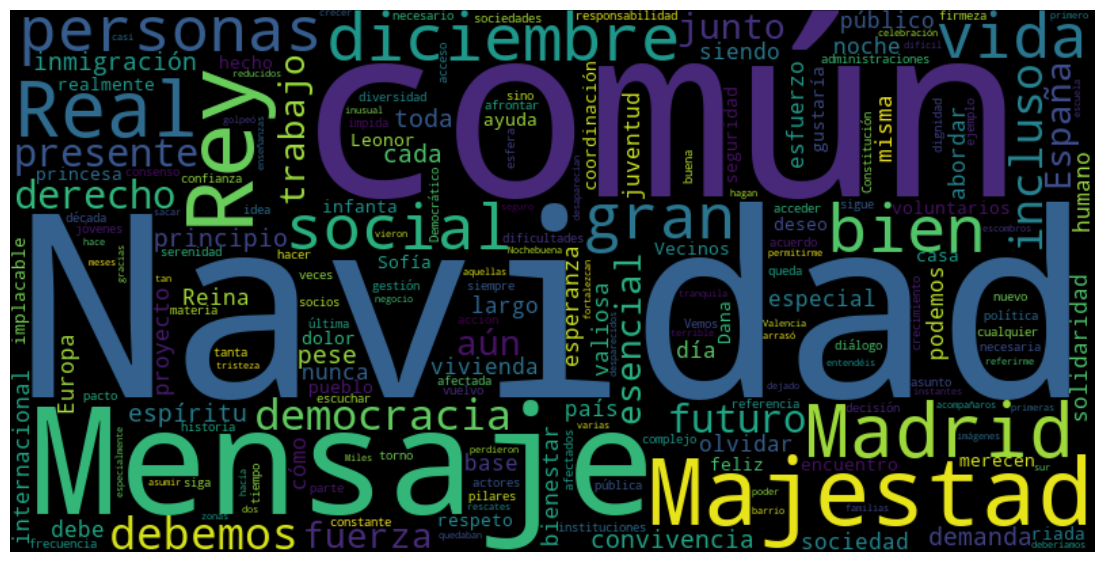

In [7]:
fig = plt.figure(figsize=(14, 18))
plt.imshow(discurso_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [8]:
spain_mask = np.array(Image.open('spain.png'))

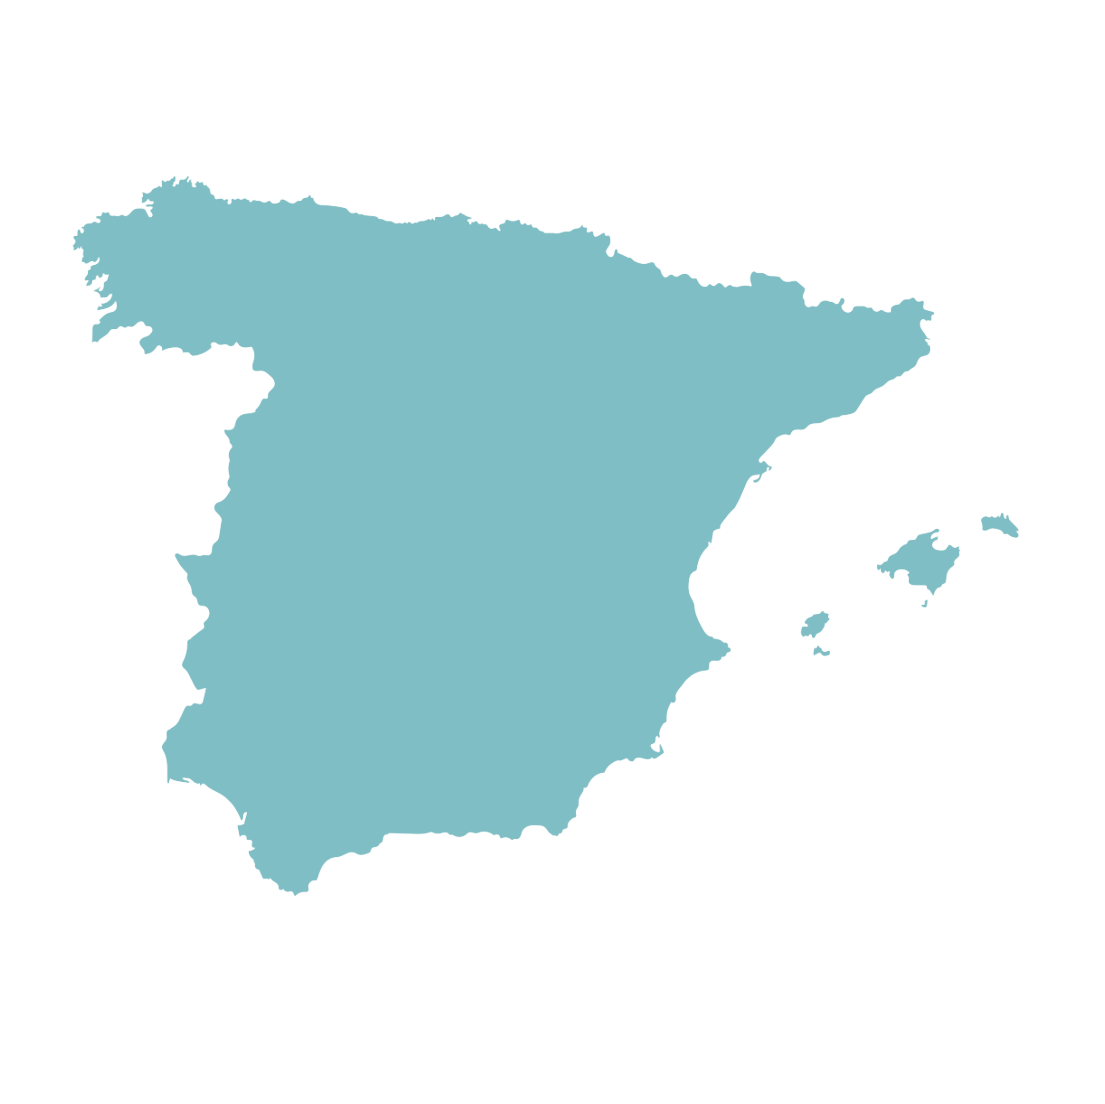

In [9]:
fig = plt.figure(figsize=(14, 18))

plt.imshow(spain_mask, cmap=plt.cm.gray, interpolation='bilinear')
plt.axis('off')
plt.show()

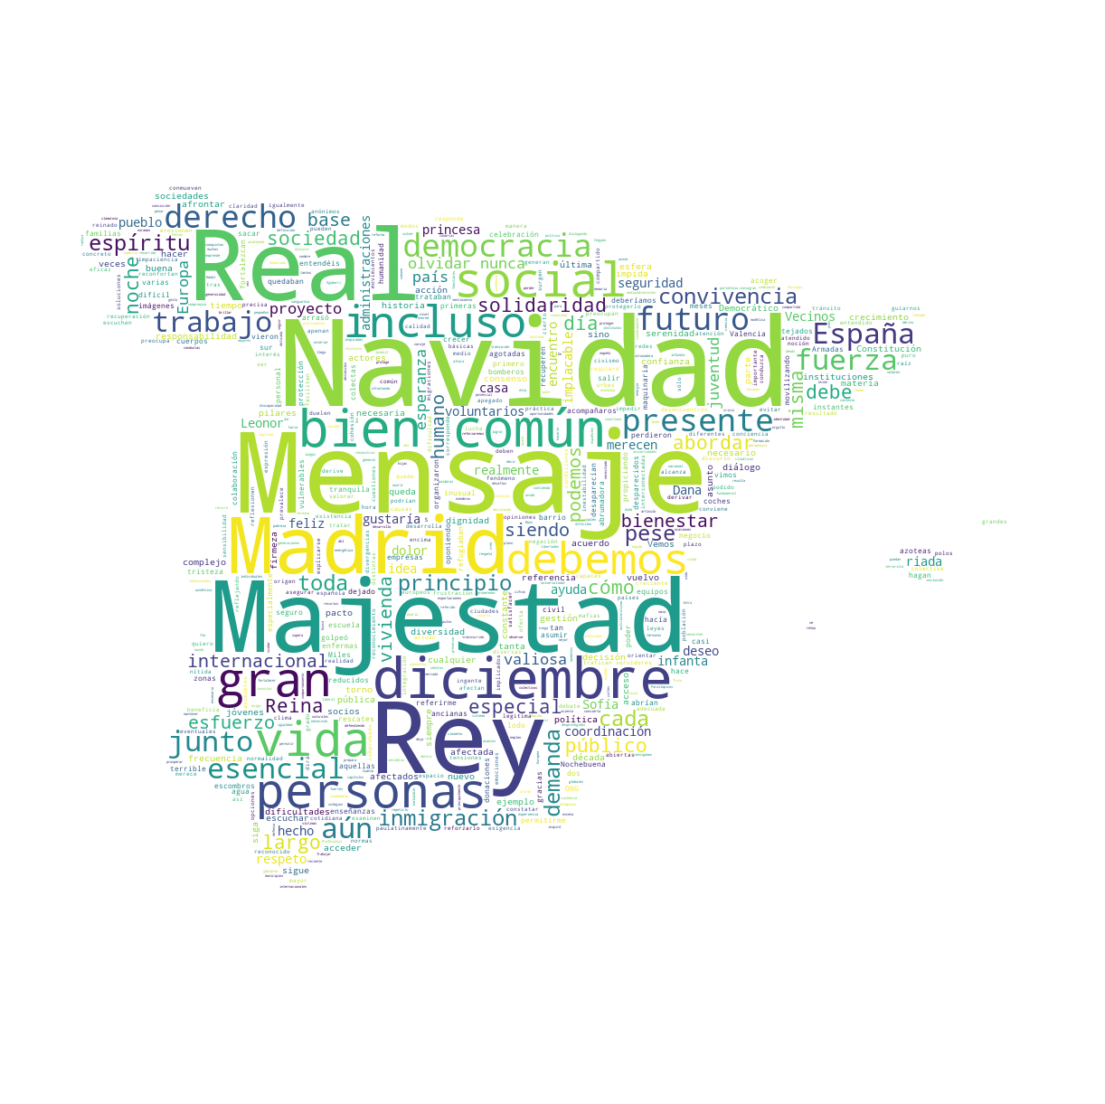

In [10]:
# instantiate a word cloud object
spain_discurso_wc= WordCloud(background_color='white', max_words=2000, mask=alice_mask, stopwords=stopwords,width=800, height=800)

# generate the word cloud
spain_discurso_wc.generate(discurso_rey)

# display the word cloud
fig = plt.figure(figsize=(14, 18))

plt.imshow(spain_discurso_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [47]:
import re

In [48]:


# 1. Obtener los datos del PDF desde la URL
# La llamada a urlopen.read() devuelve los bytes del archivo PDF
pdf_bytes = urllib.request.urlopen('https://www.boe.es/buscar/pdf/1978/BOE-A-1978-31229-consolidado.pdf').read()

# 2. Abrir los bytes en memoria como un archivo (stream)
# Esto es necesario para que PdfReader pueda leer los datos como si vinieran de un archivo.
pdf_file = io.BytesIO(pdf_bytes)

# 3. Crear un objeto PdfReader
reader = PdfReader(pdf_file)

# 4. Extraer el texto de todas las páginas y unirlas
constitucion = ""
for page in reader.pages:
    # get_text() extrae el contenido de texto de la página
    constitucion += page.extract_text() + "\n" # Agregamos un salto de línea entre páginas

# El resultado ahora está en la variable 'alice_novel' como una cadena de texto (str)
print(constitucion[:500]) # Imprime los primeros 500 caracteres para verificar
texto_limpio = constitucion.lower()
texto_limpio = re.sub(r'[^\w\s]', '', texto_limpio)
constitucion = texto_limpio

Constitución Española.
Cortes Generales
«BOE» núm. 311, de 29 de diciembre de 1978
Referencia: BOE-A-1978-31229
ÍNDICE
   
Preámbulo ................................................................... 3
TÍTULO PRELIMINAR ........................................................... 3
TÍTULO I. De los derechos y deberes fundamentales........................................ 4
CAPÍTULO PRIMERO. De los españoles y los extranjeros................................... 5
CAPÍTULO SEGUNDO. Derechos y libert


In [14]:
from nltk.corpus import stopwords
stopwords_cst = stopwords.words('spanish')

In [50]:
nuevas_palabras = ["ley", "LEGISLACIÓN", "Gobierno", "BOLETÍN","OFICIAL","Autónoma","orgánica","público","comunidades","a","Cortes","generales","diputado","podrá","así","mayoría","miembro","congreso","presidente","ejercicio","apartado","capítulo","Si","mediante","página","a "," a",
                  "podrán","consolidada","título","autónomas","cámara","estatuto","cada","refiere","presente","A","cámaras"," a ","caso","plazo","texto","forma","misma","propia","demás","efecto","toda","dos","ningún","marco","apartados"]

# 3. Usa extend() para añadir todos los elementos de 'nuevas_palabras' a 'lista_stopwords'
stopwords_cst.extend(nuevas_palabras)

In [57]:
import random

# Definimos la altura de tu WordCloud para poder calcular los tercios
# Ajusta este valor si tu WordCloud tiene otra altura (actualmente 1200 en tu ejemplo)
WC_HEIGHT = 1200 

def bandera_espana_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    
    # 1. Obtener la coordenada Y (vertical) de la palabra
    # position es una tupla (x, y)
    y_position = position[0]
    
    # 2. Calcular los límites de los tercios
    tercio_rojo_superior_limite = WC_HEIGHT / 3
    tercio_amarillo_limite = (WC_HEIGHT / 3) * 2
    
    # Colores en formato HSL (Hue, Saturation, Lightness):
    # Rojo de la bandera (H=0, S=100) - Usamos una saturación ligeramente menor (80%)
    # para darle algo de variación, y la luminosidad (L) entre 30% y 50% para que sea oscuro.
    ROJO_HSL = "hsl(0, 80%%, %d%%)"
    
    # Amarillo/Dorado de la bandera (H=45, S=100) - Usamos S=80% y L entre 50% y 70%.
    AMARILLO_HSL = "hsl(45, 80%%, %d%%)"
    
    
    # 3. Asignar el color según el tercio (coordenada Y)
    
    if y_position < tercio_rojo_superior_limite:
        # Tercio Superior (Rojo)
        return ROJO_HSL % random.randint(30, 50)
        
    elif y_position < tercio_amarillo_limite:
        # Tercio Medio (Amarillo)
        return AMARILLO_HSL % random.randint(50, 70)
        
    else:
        # Tercio Inferior (Rojo)
        return ROJO_HSL % random.randint(30, 50)

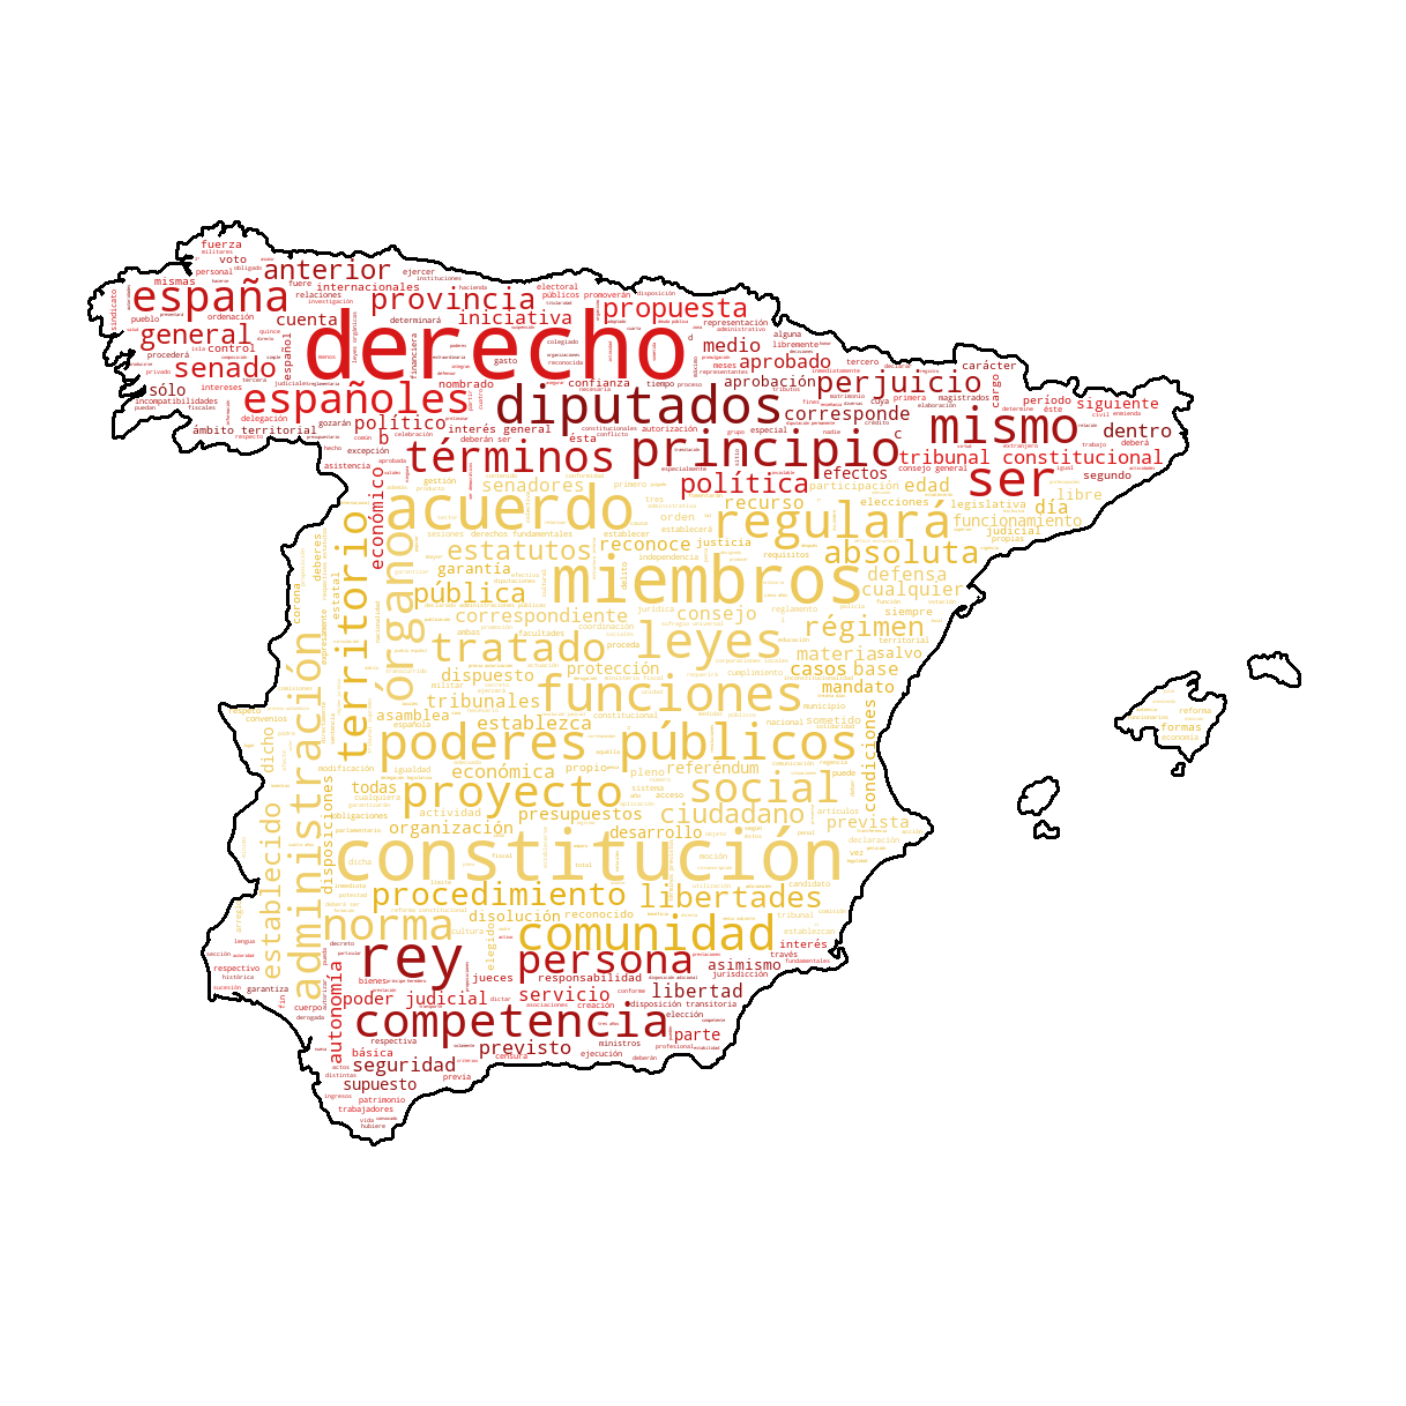

In [71]:
# instantiate a word cloud object
constitucion_wc = WordCloud(background_color='white', max_words=500, max_font_size=80,mask=alice_mask, stopwords=stopwords_cst,width=1200, height=1200,collocations=True,contour_width=3, contour_color='black',color_func=bandera_espana_color_func)

# generate the word cloud
constitucion_wc.generate(constitucion)

# display the word cloud
fig = plt.figure(figsize=(18, 18))

plt.imshow(constitucion_wc, interpolation='bilinear')
plt.axis('off')
plt.show()